In [1]:
import os
import pyvista as pv
import matplotlib.pyplot as plt
from glob import glob
from natsort import natsorted
os.environ['PYVISTA_OFF_SCREEN'] = 'true'
pv.set_jupyter_backend('client')# pv.start_xvfb()                              
pv.global_theme.trame.server_proxy_enabled = True
pv.global_theme.trame.server_proxy_prefix = "/proxy/"

In [4]:
base_pth = "/gpfs/home/cw1722/sponge/JAX-LaB/results/characteristic_curves_bgk_drainage/"
# base_pth = "/gpfs/home/cw1722/sponge/JAX-LaB/results/gdl"
out_pth = os.path.join(base_pth, "output_drainage")
out_sim = glob(out_pth + "/*.vtk")
out_sim = natsorted(out_sim)
print(len(out_sim))

251


In [10]:
idx = 1
print(out_sim[idx])
sample = pv.read(out_sim[idx])
print(sample)

/gpfs/home/cw1722/sponge/JAX-LaB/results/characteristic_curves_bgk_drainage/output_drainage/data_0001000.vtk
ImageData (0x150723fbb3a0)
  N Cells:      17548352
  N Points:     17751825
  X Bounds:     0.000e+00, 2.720e+02
  Y Bounds:     0.000e+00, 2.540e+02
  Z Bounds:     0.000e+00, 2.540e+02
  Dimensions:   273, 255, 255
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     9


In [11]:
print(sample.array_names)        # list all 17 field names 
print(sample['rho_water'].shape)

['rho', 'ux', 'uy', 'uz', 'rho_water', 'rho_air', 'p_air', 'p_water', 'flag']
(17548352,)


In [12]:
def get_phase(sample, nwp_key, wp_key, target="nwp"):
    nx, ny, nz = sample.dimensions
    nwp = sample[nwp_key].reshape(nx-1, ny-1, nz-1, order='F')
    wp = sample[wp_key].reshape(nx-1, ny-1, nz-1, order='F')
    out = nwp > wp if target == "nwp" else nwp < wp
    return out

def get_rock(sample):
    nx, ny, nz = sample.dimensions
    out = sample['flag'].reshape(nx-1, ny-1, nz-1, order='F')
    return out

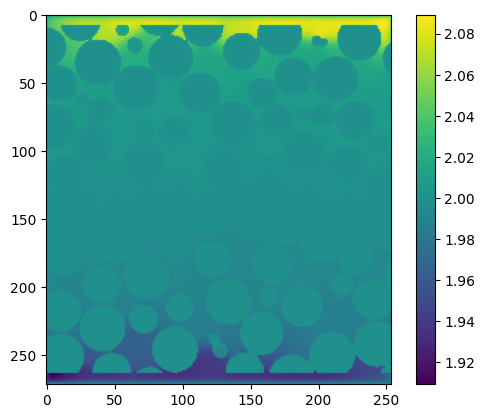

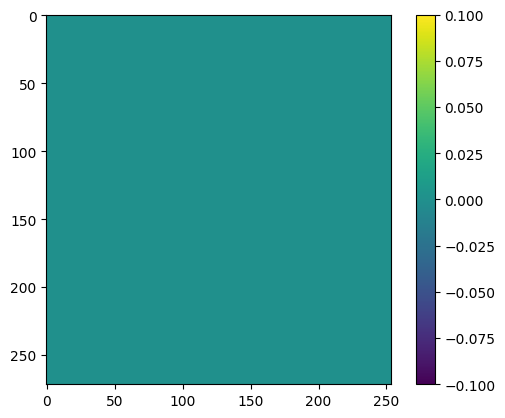

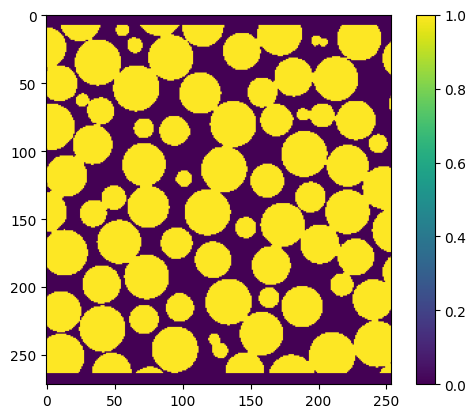

In [13]:
name = "rho_water"
nx, ny, nz = sample.dimensions
target = sample[name].reshape(nx-1, ny-1, nz-1, order='F')
phase =  get_phase(sample, "rho_air", "rho_water", target="nwp")
rock = get_rock(sample)

plt.imshow(target[:, :, 100])
plt.colorbar()
plt.show()
plt.imshow(phase[:, :, 100])
plt.colorbar()
plt.show()
plt.imshow(rock[:, :, 100])
plt.colorbar()

In [14]:
print(target)

[[[2.0046003 2.0046003 2.0046003 ... 2.0046003 2.0046003 2.0046003]
  [2.0046003 2.0046003 2.0046003 ... 2.0046003 2.0046003 2.0046003]
  [2.0046003 2.0046003 2.0046003 ... 2.0046003 2.0046003 2.0046003]
  ...
  [2.0046003 2.0046003 2.0046003 ... 2.0046003 2.0046003 2.0046003]
  [2.0046003 2.0046003 2.0046003 ... 2.0046003 2.0046003 2.0046003]
  [2.0046003 2.0046003 2.0046003 ... 2.0046003 2.0046003 2.0046003]]

 [[1.997523  2.000243  2.001996  ... 2.0190425 2.019383  2.019675 ]
  [2.0002308 2.0011337 2.0030282 ... 2.0261292 2.0262122 2.0261238]
  [2.0020833 2.0030663 2.0048223 ... 2.031084  2.0308263 2.029669 ]
  ...
  [2.0192542 2.0263388 2.031333  ... 2.0589907 2.0554202 2.0479245]
  [2.0194561 2.026253  2.0309634 ... 2.0554447 2.0524454 2.0461857]
  [2.019645  2.0261505 2.0297441 ... 2.0479524 2.046215  2.0421922]]

 [[2.0051692 2.0041013 2.0055108 ... 2.029175  2.0284278 2.0268564]
  [2.0041397 2.0029166 2.004407  ... 2.0369434 2.0353305 2.0314634]
  [2.0056388 2.0044756 2.006005 